In [ ]:

# Machine Learning / Deep Learning
import sys
sys.path.append(r'c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\utils')
from functions import symmetric_mean_absolute_percentage_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import Dropout

# Configuración del entorno
import json
import os
import warnings
import re
import numpy as np
import pandas as pd

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)


# modelado 

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)


# Visualización

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.graph_objects as go

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")


# Optimización

import optuna
import optuna.visualization as vis

np.random.seed(42)
from optuna.samplers import TPESampler # reproductibilidad con optuna


In [2]:
# generación automatica de semillas para la reproductibilidad

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# carga de datos desde archivos csv
# se descomentan solo los de nvidia y syp 
tickets = [
    "NVDA",
    "^SPX"
    #"AMD",
    #"BTC-USD",
    #"^NDX",
    #"^VIX",
    #"UBSFY"
]
# se cargan las fechas
dates = pd.read_csv("../data/csv/SPX_data.csv")
# se crea un dataframe con las fechas de close para almacenar los precios de cierre
date_close = pd.DataFrame({
    "Date": pd.to_datetime(dates["Date"])
})

# se recorren los tickets, se lee el archivo asociado al ticket y se
# carga en el df el precio de cierre

for ticket in tickets: 
    file_name = ticket.replace("^", "") # se quita el caracter ^
    data_ticket = pd.read_csv(f"../data/csv/{file_name}_data.csv") # se lee el archivo csv del ticket correspondiente
    data_ticket["Date"] = pd.to_datetime(data_ticket["Date"]) # se formatea la columna Date a fecha

    # se define el nombre de la columna de precios de cierre
    close_column = f"{file_name}_Close"

    # se hace left join del df de las fechas con el df del ticket creado, por fechas
    date_close = pd.merge(
        date_close, # primer df
        data_ticket[["Date", close_column]].rename(columns={close_column: file_name}),
        # se escogen las columnas date y cierre del df del ticket y se renombra la columna de precio de cierre con el nombre del ticket
        on="Date", # columna para hacer el merge
        how="left" # tipo de merge
    )

In [4]:
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_dat_close = df_data_close.sort_values(by="Date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()

,Date,NVDA,SPX
0,2021-01-04,13.077453,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579823,3748.139893
3,2021-01-07,13.307318,3803.790039
4,2021-01-08,13.240255,3824.679932


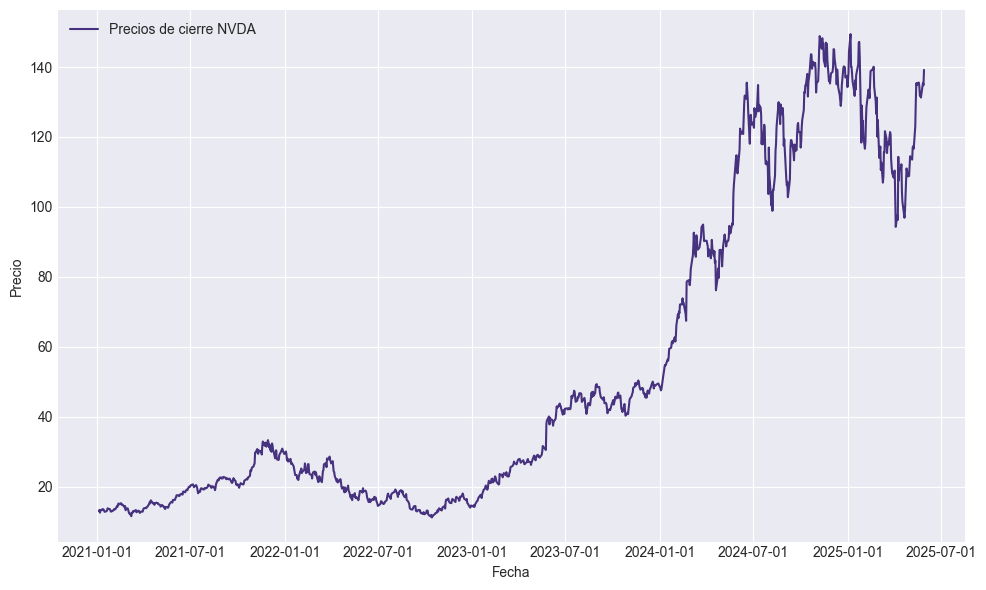

In [5]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(df_data_close["Date"], df_data_close["NVDA"], label="Precios de cierre NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [6]:
# se hace una copia para la manipulación de los datos y se deja un porcentaje para extrapolar el comportamiento del modelo
df_data_close_copy = df_data_close.copy()
percentage = 0.9 # porcentaje de datos para folds
folds_data_size = int(len(df_data_close_copy) * percentage) # tamaño de los datos para folds
folds_data = df_data_close_copy.iloc[:folds_data_size] # datos para folds
val_data = df_data_close_copy.iloc[folds_data_size:] # datos para validación final

# se calcula la fecha donde se toman los datos de validación
val_start_date = folds_data["Date"][-1:].values[0]
folds_data.tail()

,Date,NVDA,SPX
990,2024-12-10,135.040588,6034.910156
991,2024-12-11,139.279648,6084.189941
992,2024-12-12,137.310089,6051.250000
993,2024-12-13,134.220764,6051.089844
994,2024-12-16,131.971237,6074.080078


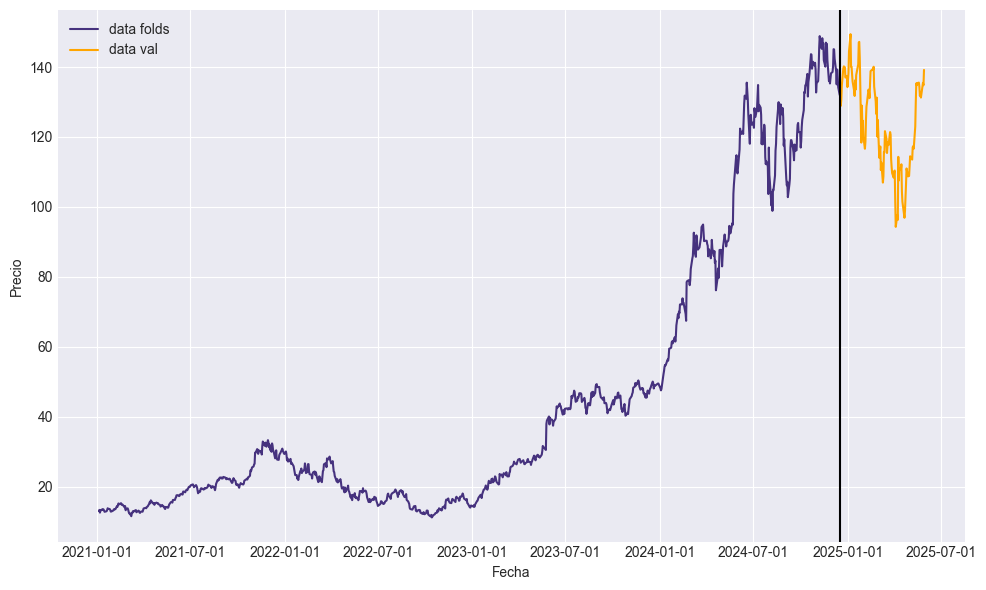

In [7]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(folds_data["Date"], folds_data["NVDA"], label="data folds")
plt.plot(val_data["Date"], val_data["NVDA"], label="data val", color='orange')
plt.axvline(val_start_date, color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [8]:
# Ahora se crea la función que creará las ventanas con los rezagos para ingresar en la red.
# para que la RNN reciba los datos como un tensor de orden 3
# la función crea un dataset para los datos de entrenamiento de la RNN.
# create_dataset es una función que genera los datos de entrada X y los datos de salida y
# se crea una ventana de datos de tamaño 1 (pero este será un hiperparámetro de la red) sobre los precios y se almacena
# el próximo precio como objetivo. El array X es redimensionado como un array 3D como lo requiere la RNN:
# [samples, time_steps, features] 

def create_dataset(data, time_step=1):
    X, y = [], [] # se crean dos arrays vacíos que devolverán los datos separados por ventanas
    for i in range(len(data) - time_step - 1):
        arr_2_add = data[i : (i + time_step), :]
        # print(len(arr_2_add))
        X.append(arr_2_add)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# ejemplo


In [9]:
# se define ahora una función que ayudará a construir la rnn de forma paramétrica,
# input_timesteps: numero de rezagos
# n_features: numero de características (variables exogenas + variables objetivo)
# units: numero de unidades de la capa recurrente
# lr: tasa de aprendizaje
def build_rnn(input_timesteps, n_features, units, lr,  dropout_rate=0.2, recurrent_dropout_rate=0.1):
    model = models.Sequential() # se inicializa el modelo
    model.add(layers.Input(shape=(input_timesteps, n_features))) # se añade la capa de entrada, son las n_features
    # cada una con dimensión input_timesteps
    model.add(layers.SimpleRNN(
        units=units, 
        activation="tanh", # función de activación
        stateful=False,
        dropout=dropout_rate, # regularización en las entradas
        recurrent_dropout=recurrent_dropout_rate  # regularización en las conexiones internas
        )
    ) # se añade la capa RNN con las unidades y función de activación tanh
    model.add(layers.Dense(units=1, activation="linear")) # se añade la capa densa de salida con una neurona y función de activación lineal
    model.compile(
        optimizer = optimizers.Adam(learning_rate=lr), # se compila el modelo con el optimizador Adam y la tasa de aprendizaje lr
        loss = "mean_squared_error" # se utiliza el error cuadrático medio como función de pérdida
    )

    return model
# el modelo tiene una neurona de salida. SIn embargo, al usar la definición por ventanas, se toman secuencias de una longitud que tienen 
# como etiqueta otro valor, por lo que el resultado es una neurona pero devuelve un vector

In [10]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = len(val_data)
gap = 8 # distancia (cantidad de observaciones) que se deja entre train y test
tscv = TimeSeriesSplit(test_size=size_test, gap=gap)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo RNN con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [11]:

def objective(trial):

    # parametros de la RNN
    input_timesteps = trial.suggest_categorical('input_timesteps', [1, 7, 15, 30, 90])
    units = trial.suggest_int("units", 32, 128, step=32)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    epochs = trial.suggest_int("epochs", 40, 120)
    dropout = trial.suggest_float("dropout_rate", 0.0, 0.3)
    recurrent_dropout = trial.suggest_float("recurrent_dropout_rate", 0.0, 0.3)


    # se redimensionan los datos de folds_data
    data_raw = folds_data[["NVDA", "SPX"]].values.reshape(-1, 2)

    # Crear dataset base
    X_fold, y_fold = create_dataset(data_raw, input_timesteps)
    X_fold = X_fold.reshape(X_fold.shape[0], X_fold.shape[1], X_fold.shape[2])

    
    # se almacenan las métricas por fold
    mapes, maes, rmses, smapes = [], [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_fold)):
        # reproductibilidad en cada fold
        tf.random.set_seed(42)
        np.random.seed(42)


        # Escalado por fold 
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # fold de entrenamiento
        X_train_raw = X_fold[train_idx]
        y_train_raw = y_fold[train_idx].reshape(-1, 1)

        # fold de validación
        X_test_raw  = X_fold[test_idx]
        y_test_raw  = y_fold[test_idx].reshape(-1, 1)

        # Reescalado
        X_train = scaler_X.fit_transform(X_train_raw.reshape(-1, X_fold.shape[2])).reshape(X_train_raw.shape)
        X_test  = scaler_X.transform(X_test_raw.reshape(-1, X_fold.shape[2])).reshape(X_test_raw.shape)

        y_train = scaler_y.fit_transform(y_train_raw)
        y_test  = scaler_y.transform(y_test_raw)


        #  se define el modelo con la función build_rnn
        n_features = X_train.shape[-1] # cantidad de features (en este caso son 2, la NVDA y SPX)
        model = build_rnn(
            input_timesteps,
            n_features,
            units,
            lr,
            dropout,
            recurrent_dropout
        )

        # se fija el modelo
        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch,
            shuffle=False,
            verbose=0
        )

       
        # Predicción sobre el fold de prueba
        y_pred_scaled = model.predict(X_test, verbose=0)

        # se devuelven los datos a las escalas originales
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_test)

        
        # Métricas de error 
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape = symmetric_mean_absolute_percentage_error(y_true, y_pred)

        # se añaden a los arrays
        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)

        # se guarda registro del trial como atributo de usuario del study para poder consultarlo luego
        trial.set_user_attr(f"fold_{fold_idx + 1}", {"mae": mae, "mape": mape, "rmse": rmse, "smape": smape})
        # se reporta el valor de la media de los mapes
        trial.report(np.mean(mapes), step=fold_idx)

    
    median_mape = float(np.mean(mapes))
    #trial.set_user_attr("median_mape", median_mape)
    return median_mape


In [12]:
# se ejecuta la optimización con Optuna
print("Optimización con Optuna")
# se crea el caso de estudio, con el objetivo y la función a minimizar
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2025-12-04 19:41:45,280] A new study created in memory with name: no-name-00d04bfc-7760-4485-9475-907b75ca7fbb


Optimización con Optuna


[I 2025-12-04 19:43:02,668] Trial 0 finished with value: 0.19480591829857088 and parameters: {'input_timesteps': 1, 'units': 128, 'lr': 0.0010148559396200635, 'batch_size': 64, 'epochs': 117, 'dropout_rate': 0.20304908662022048, 'recurrent_dropout_rate': 0.037270873639919065}. Best is trial 0 with value: 0.19480591829857088.
[I 2025-12-04 19:46:42,819] Trial 1 finished with value: 0.13028311005277726 and parameters: {'input_timesteps': 90, 'units': 32, 'lr': 0.0029781032922151563, 'batch_size': 16, 'epochs': 82, 'dropout_rate': 0.05763945159865421, 'recurrent_dropout_rate': 0.0964673762949995}. Best is trial 1 with value: 0.13028311005277726.
[I 2025-12-04 19:47:14,502] Trial 2 finished with value: 0.3276775997259393 and parameters: {'input_timesteps': 1, 'units': 32, 'lr': 0.00011798579692243988, 'batch_size': 128, 'epochs': 103, 'dropout_rate': 0.21424590891830939, 'recurrent_dropout_rate': 0.1411176498103001}. Best is trial 1 with value: 0.13028311005277726.
[I 2025-12-04 19:47:50,5

en cada trial se devuelven datos relacionados con
- valor mape mínimo
- conjunto de hiperparámetros
- trial que ha dejado menor mape (o métrica seleccionada) hasta el momento


In [13]:
# mejor conjunto de hiperparámetros
study.best_params

{'input_timesteps': 15,
 'units': 128,
 'lr': 0.0008185155521590812,
 'batch_size': 32,
 'epochs': 51,
 'dropout_rate': 0.020271579906937304,
 'recurrent_dropout_rate': 0.2838158578659118}

In [14]:
# info de los trials 
# se extraen los trials
trials = study.get_trials()
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs
    print(attrs)

{'fold_1': {'mae': 1.401789648038847, 'mape': 0.085274500710159, 'rmse': 1.63450110364347, 'smape': 0.08340484516567667}, 'fold_2': {'mae': 9.166635461755703, 'mape': 0.24467004049280736, 'rmse': 9.988994678770663, 'smape': 0.28141101832484866}, 'fold_3': {'mae': 9.440055812801326, 'mape': 0.19677641218035422, 'rmse': 9.623969441186052, 'smape': 0.21858018678915223}, 'fold_4': {'mae': 27.003887898213154, 'mape': 0.279197041197619, 'rmse': 28.419411224657527, 'smape': 0.32560244178599884}, 'fold_5': {'mae': 21.590217109199042, 'mape': 0.1681115969119148, 'rmse': 22.166740623427298, 'smape': 0.18410129483265025}}
{'fold_1': {'mae': 0.6263556265616205, 'mape': 0.03587695362950946, 'rmse': 0.841834152746865, 'smape': 0.03663375111068913}, 'fold_2': {'mae': 5.58529499844388, 'mape': 0.150869766429213, 'rmse': 6.03624104760484, 'smape': 0.16398745544758564}, 'fold_3': {'mae': 1.5637950038050745, 'mape': 0.03163281410680515, 'rmse': 1.9422515143386712, 'smape': 0.03233621819133729}, 'fold_4':

In [15]:
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas 
# en cada registro (las claves no varían)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": value.get("fold"),
                "mape": value.get("mape"),
                "mae": value.get("mae"),
                "rmse": value.get("rmse"),
                "smape": value.get("smape")
            }) 
df_metrics = pd.DataFrame(rows)
df_metrics.head()

,trial,fold,mape,mae,rmse,smape
0,0,None,0.085275,1.401790,1.634501,0.083405
1,0,None,0.244670,9.166635,9.988995,0.281411
2,0,None,0.196776,9.440056,9.623969,0.218580
3,0,None,0.279197,27.003888,28.419411,0.325602
4,0,None,0.168112,21.590217,22.166741,0.184101


In [16]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

,mape,mae,rmse,smape
count,250.000000,250.000000,250.000000,250.000000
mean,0.108679,7.626014,8.513465,0.121221
std,0.103204,9.500162,10.118305,0.132999
min,0.018887,0.586338,0.748106,0.018925
25%,0.040777,1.453981,1.905749,0.041490
50%,0.067226,3.958494,4.579198,0.068549
75%,0.140844,9.169000,10.123577,0.145192
max,0.653047,62.811000,65.446697,0.975220


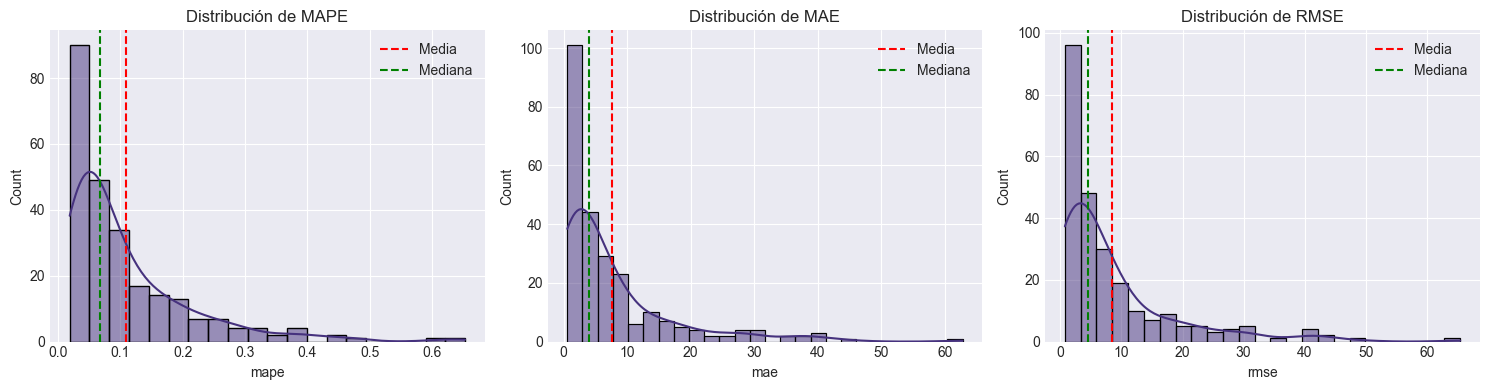

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax)
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()


In [18]:
summary = df_metrics.groupby("trial")[["mape", "mae", "rmse", "smape"]].agg(["mean", "std"])
summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.sort_values("mape_mean")
summary.head()


,mape_mean,mape_std,mae_mean,mae_std,rmse_mean,rmse_std,smape_mean,smape_std
trial,,,,,,,,
46,0.031155,0.009507,1.850697,1.234648,2.402328,1.607351,0.031519,0.010111
23,0.037218,0.012284,2.412801,1.744549,3.129879,2.361388,0.038120,0.013080
40,0.037626,0.014981,2.297966,1.529931,2.893990,1.998944,0.038430,0.015974
42,0.037639,0.009758,2.519520,2.132898,3.027505,2.491126,0.037198,0.009170
12,0.038278,0.022519,2.902483,3.163938,3.639952,3.955017,0.039434,0.024289


In [19]:
# validación out-of-sample usando el conjunto de hiperparametros arrojado por optuna
# se configuran los formatos de los datos para fijar la rnn
best = study.best_params
lags = best["input_timesteps"]

# escaladores de los datos para estandarizar
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# ajustar con datos de folds y se escala
train_values = folds_data[["NVDA", "SPX"]].values.reshape(-1,2)
scaler_X.fit(train_values)
scaler_y.fit(train_values[:, [0]]) # se toma solo la columna NVDA

# 
scaled_train = np.hstack([
    scaler_X.transform(folds_data[["NVDA", "SPX"]]),
])
scaled_val = np.hstack([
    scaler_X.transform(val_data[["NVDA", "SPX"]]),
])

# Crear dataset para fijar
X_train, y_train = create_dataset(scaled_train, lags)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])

# Preparar datos Out of sample: se toman los ultimos lags de entrenamiento para tener la misma longitud en las predicciones que se dejaron para validación
combined = np.concatenate([scaled_train[-lags:], scaled_val])
X_val, y_val = create_dataset(combined, lags)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])

model = build_rnn(
    input_timesteps=lags,
    n_features=X_train.shape[-1],
    units=best["units"],
    lr=best["lr"],
    dropout_rate=best.get("dropout_rate", 0.0),
    recurrent_dropout_rate=best.get("recurrent_dropout_rate", 0.0)
)

# número de iteraciones en las que se fija el modelo
lista_errores = []
iters = 1

for i in range(iters):
    model.fit(
        X_train, y_train, # se fija el modelo a los datos de entrenamiento
        epochs = study.best_params["epochs"],
        shuffle=False, # evita muestreo aleatorio de los datos
        batch_size = study.best_params["batch_size"],
        verbose=0
    )

    # --- Predicción sobre el conjunto OOS ---
    y_pred_scaled = model.predict(X_val, verbose=0) # se obtienen las predicciones del modelo
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)) # se reescalan las predicciones en en su rango original
    y_true = scaler_y.inverse_transform(y_val.reshape(-1,1)) # se reescalan los valores en su rango original

    # --- Métricas de desempeño ---
    mape_iter = mean_absolute_percentage_error(y_true, y_pred) 
    mae_iter = mean_absolute_error(y_true, y_pred)
    rmse_iter = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    lista_errores.append({
        "iter": i + 1,
        "mae": mae_iter,
        "mape": mape_iter,
        "rmse": rmse_iter,
        "forecasts": y_pred.flatten().tolist()
    })





In [20]:
# Cálculo de métricas agregadas

mape_median = np.median([x["mape"] for x in lista_errores])
mae_median  = np.median([x["mae"] for x in lista_errores])
rmse_median = np.median([x["rmse"] for x in lista_errores])

# Convertir las predicciones a lista nativa (para que sea JSON serializable)
predictions_list = np.asarray(lista_errores[-1]["forecasts"]).astype(float).ravel().tolist()

# Crear el DataFrame medians_df
medians_df = pd.DataFrame({
    "mape_median": [mape_median],
    "mae_median": [mae_median],
    "rmse_median": [rmse_median],
    "predictions": [predictions_list]  # lista dentro de una celda
})

# Exportar a JSON sin error
medians_df.to_json("../data/best_parameters/preds_rnn.json", orient="records")
print(f"datos exportados")

datos exportados


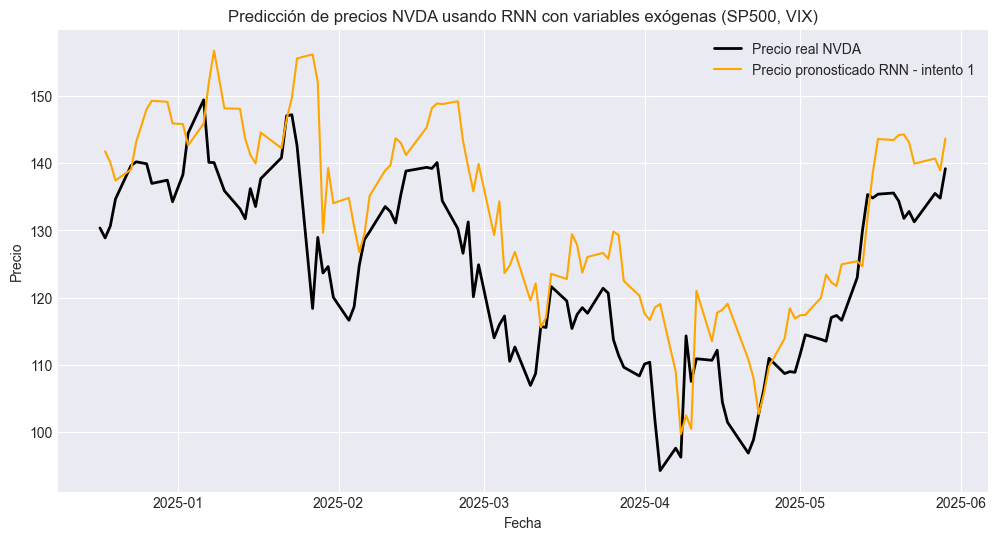

In [21]:
# se grafican los datos de prueba vs los pronosticos dados en cada una de las iters
#112
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(X_data_test)], df_data_close["NVDA"][:-len(X_data_test)], label="Precio real NVDA - train", color="gray")
plt.plot(val_data["Date"][-len(val_data):], val_data["NVDA"][-len(val_data):], label="Precio real NVDA", color="black", alpha=1, linewidth=2)
for i, resultado in enumerate(lista_errores):
    forecast_rescaled = resultado["forecasts"]
    plt.plot(val_data["Date"][-len(forecast_rescaled):], forecast_rescaled, label=f"Precio pronosticado RNN - intento {i+1}", alpha=1, color='orange')
#plt.plot(val_data["Date"][-len(predictions_rescaled):], predictions_rescaled, label="Precio pronosticado RNN", color="orange")
#plt.plot(train_data["Date"], train_data["NVDA"], label="train", color="gray")
#plt.plot(test_data["Date"], test_data["NVDA"], label="test", color="orange")
#plt.axvline(fecha_corte, color="black", linestyle="-")
plt.title("Predicción de precios NVDA usando RNN con variables exógenas (SP500, VIX)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.show()

In [22]:
# métricas de validación out of sample
# se toman los valores promedio de cada una de las medidas
list_mapes, list_maes, list_rmses = [], [], []
for el in lista_errores:
    list_mapes.append(el["mape"])
    list_maes.append(el["mae"])
    list_rmses.append(el["rmse"])
print(f"mape prom validacion: {np.mean(list_mapes)}")
print(f"mae prom validacion: {np.mean(list_maes)}")
print(f"rmse prom validacion: {np.mean(list_rmses)}")

mape prom validacion: 0.07190350202641761
mae prom validacion: 8.702532681551846
rmse prom validacion: 9.945154531087558
